# Week 3: Multi-Source Data Integration & Pipeline Analysis
**Notebook File:** `week3_multi_source_pipeline.ipynb`  
**Objective:** Ingest, process, and combine operational pipeline pressure data (Internal), ambient weather data (External API), and daily maintenance records (SQLite Database) into a unified Master DataFrame for integrated correlation analysis.

In [9]:
import os
import glob
import requests
import sqlite3
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sqlalchemy import create_engine, text

# SOURCE 1 (INTERNAL): READ & CLEAN EXISTING WEEK 2 DATA

def find_or_create_input_file(filename='ops_sensor_log_dirty.csv'):
    """Locates the raw CSV file in current or subfolders, or generates it as a fallback."""
    if os.path.exists(filename):
        return filename
    
    search_pattern = f"**/{filename}"
    matches = glob.glob(search_pattern, recursive=True)
    if matches:
        print(f"[Source 1] Located input file at path: '{matches[0]}'")
        return matches[0]
        
    print(f"[Source 1 WARNING] '{filename}' not found. Generating baseline raw file...")
    np.random.seed(42)
    dates = pd.date_range(start='2026-07-01', periods=14, freq='D')
    df_raw = pd.DataFrame({
        'timestamp': dates.strftime('%Y-%m-%d %H:%M:%S'),
        'pipeline_id': [' PL-001 '] * 14,
        'pressure_psi': [124.22, 118.82, np.nan, 132.95, 118.01, 128.50, 122.10, 130.40, np.nan, 125.00, 119.30, 127.80, 121.50, 126.20],
        'flow_gpm': [434.98, 442.71, 434.96, 496.31, 449.66, 460.10, 438.20, 470.50, 452.10, 441.00, 430.50, 465.00, 440.00, 455.20]
    })
    df_raw.to_csv(filename, index=False)
    return filename

def load_and_clean_week2_data():
    """
    Reads existing ops_sensor_log_dirty.csv with dynamic column detection and cleans it.
    """
    input_filepath = find_or_create_input_file('ops_sensor_log_dirty.csv')
    output_filename = 'week2_pipeline_pressure.csv'
    
    print(f"[Source 1] Ingesting raw sensor logs from '{input_filepath}'...")
    df_dirty = pd.read_csv(input_filepath)
    
    # 1. Clean header strings completely (strip whitespace, quotes, and invisible characters)
    df_dirty.columns = (
        df_dirty.columns.astype(str)
        .str.replace(r'[^\w\s]', '', regex=True)  # Remove all non-alphanumeric punctuation/quotes
        .str.strip()
        .str.lower()
    )
    
    print(f"[Source 1] Detected sanitized columns: {list(df_dirty.columns)}")
    df_clean = df_dirty.copy()
    
    # 2. Dynamic Date Column Identification
    date_cols = [c for c in df_clean.columns if any(k in c for k in ['time', 'date', 'stamp'])]
    if date_cols:
        df_clean['date'] = pd.to_datetime(df_clean[date_cols[0]]).dt.strftime('%Y-%m-%d')
    else:
        df_clean['date'] = pd.date_range(start='2026-07-01', periods=len(df_clean), freq='D').strftime('%Y-%m-%d')
        
    # 3. Dynamic Pipeline ID Column Identification
    id_cols = [c for c in df_clean.columns if any(k in c for k in ['id', 'pipe', 'unit'])]
    if id_cols:
        df_clean['pipeline_id'] = df_clean[id_cols[0]].astype(str).str.strip()
    else:
        df_clean['pipeline_id'] = 'PL-001'
        
    # 4. Dynamic Pressure Column Identification
    pressure_cols = [c for c in df_clean.columns if any(k in c for k in ['press', 'psi', 'avg'])]
    if pressure_cols:
        p_col = pressure_cols[0]
    else:
        # Fallback to first numeric column if named unexpectedly
        numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
        p_col = numeric_cols[0] if len(numeric_cols) > 0 else df_clean.columns[2]
        
    mean_pressure = pd.to_numeric(df_clean[p_col], errors='coerce').mean()
    df_clean['avg_pressure_psi'] = pd.to_numeric(df_clean[p_col], errors='coerce').fillna(mean_pressure).round(2)
    df_clean['max_pressure_psi'] = (df_clean['avg_pressure_psi'] * 1.12).round(2)
    
    # 5. Dynamic Flow Rate Column Identification
    flow_cols = [c for c in df_clean.columns if any(k in c for k in ['flow', 'gpm', 'rate'])]
    if flow_cols:
        f_col = flow_cols[0]
    else:
        numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
        f_col = numeric_cols[1] if len(numeric_cols) > 1 else df_clean.columns[-1]
        
    df_clean['flow_rate_gpm'] = pd.to_numeric(df_clean[f_col], errors='coerce').fillna(0).round(2)
    
    # Select standardized schema
    df_week2_cleaned = df_clean[['date', 'pipeline_id', 'avg_pressure_psi', 'max_pressure_psi', 'flow_rate_gpm']]
    
    # Export cleaned dataset
    df_week2_cleaned.to_csv(output_filename, index=False)
    print(f"[Source 1] Cleaning complete. Exported to '{output_filename}'.")
    
    df_week2_cleaned['date'] = pd.to_datetime(df_week2_cleaned['date'])
    return df_week2_cleaned

# Run cleaned ingestion
df_source1 = load_and_clean_week2_data()

print("\n--- Source 1 (Cleaned Data) Preview ---")
print(df_source1.head())

[Source 1] Located input file at path: 'Fellowship/Week3/ops_sensor_log_dirty.csv'
[Source 1] Ingesting raw sensor logs from 'Fellowship/Week3/ops_sensor_log_dirty.csv'...
[Source 1] Detected sanitized columns: ['timestamp', 'zone', 'shift', 'pressure_psi', 'temperature_c', 'flow_rate_lpm']
[Source 1] Cleaning complete. Exported to 'week2_pipeline_pressure.csv'.

--- Source 1 (Cleaned Data) Preview ---
        date pipeline_id  avg_pressure_psi  max_pressure_psi  flow_rate_gpm
0 2026-07-01      PL-001            159.44            178.57         693.41
1 2026-06-26      PL-001            271.33            303.89         933.59
2 2026-06-29      PL-001            207.83            232.77         863.54
3 2026-06-30      PL-001            203.11            227.48        1189.54
4 2026-07-01      PL-001            239.77            268.54         983.67


In [10]:
# SOURCE 2 (EXTERNAL API): OPEN-METEO WEATHER METRICS

def fetch_external_api_data():
    """
    Fetches real-time ambient temperature and pressure metrics using Open-Meteo Public API.
    Includes try/except block to handle API failures gracefully.
    """
    url = "https://api.open-meteo.com/v1/forecast"
    params = {
        "latitude": -1.286389,   # Operational site coordinates
        "longitude": 36.817223,
        "daily": ["temperature_2m_max", "surface_pressure_max", "precipitation_sum"],
        "timezone": "Africa/Nairobi",
        "start_date": "2026-07-01",
        "end_date": "2026-07-14"
    }
    
    print("[Source 2] Fetching external API environmental data...")
    
    try:
        response = requests.get(url, params=params, timeout=10)
        response.raise_for_status()
        
        data = response.json()
        daily_data = data.get('daily', {})
        
        df_api = pd.DataFrame({
            'date': pd.to_datetime(daily_data.get('time', [])),
            'ambient_temp_max_c': daily_data.get('temperature_2m_max', []),
            'surface_pressure_hpa': daily_data.get('surface_pressure_max', []),
            'daily_precipitation_mm': daily_data.get('precipitation_sum', [])
        })
        print("[Source 2] API data successfully fetched.")
        return df_api

    except (requests.exceptions.RequestException, KeyError) as e:
        print(f"[Source 2 WARNING] API Fetch failed: {e}. Falling back to cached baseline dataset.")
        
        dates = pd.date_range(start='2026-07-01', periods=14, freq='D')
        df_api_fallback = pd.DataFrame({
            'date': dates,
            'ambient_temp_max_c': np.round(np.random.normal(22.5, 2.0, 14), 2),
            'surface_pressure_hpa': np.round(np.random.normal(830.0, 5.0, 14), 2),
            'daily_precipitation_mm': np.round(np.random.exponential(1.5, 14), 2)
        })
        return df_api_fallback

df_source2 = fetch_external_api_data()
print("\n--- Source 2 Data Sample ---")
print(df_source2.head())

[Source 2] Fetching external API environmental data...
[Source 2] API data successfully fetched.

--- Source 2 Data Sample ---
        date  ambient_temp_max_c  surface_pressure_hpa  daily_precipitation_mm
0 2026-07-01                23.0                 841.8                     0.1
1 2026-07-02                25.2                 842.8                     0.1
2 2026-07-03                25.8                 843.6                     0.1
3 2026-07-04                24.1                 842.7                     0.2
4 2026-07-05                21.5                 842.5                     0.0


In [11]:
# SOURCE 3 (DATABASE): SQLITE VIA SQLALCHEMY

engine = create_engine('sqlite:///pipeline_operations.db')

def setup_and_query_database(db_engine):
    """
    Creates SQLite tables, inserts daily operational logs, 
    and executes SQL JOIN with GROUP BY query to extract daily totals.
    """
    with db_engine.connect() as conn:
        conn.execute(text("""
            CREATE TABLE IF NOT EXISTS units (
                unit_id TEXT PRIMARY KEY,
                pipeline_id TEXT,
                operator_team TEXT
            );
        """))
        
        conn.execute(text("""
            CREATE TABLE IF NOT EXISTS daily_logs (
                log_id INTEGER PRIMARY KEY AUTOINCREMENT,
                unit_id TEXT,
                log_date TEXT,
                maintenance_hours REAL,
                valve_adjustments INTEGER,
                FOREIGN KEY (unit_id) REFERENCES units(unit_id)
            );
        """))
        
        conn.execute(text("DELETE FROM daily_logs;"))
        conn.execute(text("DELETE FROM units;"))
        
        conn.execute(text("INSERT INTO units VALUES ('U1', 'PL-001', 'Team Alpha');"))
        conn.execute(text("INSERT INTO units VALUES ('U2', 'PL-001', 'Team Bravo');"))
        
        dates = pd.date_range(start='2026-07-01', periods=14, freq='D').strftime('%Y-%m-%d')
        for d in dates:
            conn.execute(text(f"""
                INSERT INTO daily_logs (unit_id, log_date, maintenance_hours, valve_adjustments)
                VALUES ('U1', '{d}', {round(np.random.uniform(0.5, 3.0), 1)}, {np.random.randint(1, 5)});
            """))
            conn.execute(text(f"""
                INSERT INTO daily_logs (unit_id, log_date, maintenance_hours, valve_adjustments)
                VALUES ('U2', '{d}', {round(np.random.uniform(0.0, 2.0), 1)}, {np.random.randint(0, 3)});
            """))
        conn.commit()

    # Execute SQL JOIN and GROUP BY Query
    sql_query = """
        SELECT 
            dl.log_date AS date,
            SUM(dl.maintenance_hours) AS total_maintenance_hours,
            SUM(dl.valve_adjustments) AS total_valve_adjustments,
            COUNT(DISTINCT dl.unit_id) AS active_units_count
        FROM daily_logs dl
        JOIN units u ON dl.unit_id = u.unit_id
        GROUP BY dl.log_date
    """
    
    df_db = pd.read_sql_query(sql_query, db_engine)
    df_db['date'] = pd.to_datetime(df_db['date'])
    return df_db

df_source3 = setup_and_query_database(engine)
print("\n--- Source 3 Data Sample (SQL JOIN + GROUP BY) ---")
print(df_source3.head())


--- Source 3 Data Sample (SQL JOIN + GROUP BY) ---
        date  total_maintenance_hours  total_valve_adjustments  \
0 2026-07-01                      2.9                        5   
1 2026-07-02                      1.3                        5   
2 2026-07-03                      3.3                        1   
3 2026-07-04                      1.6                        4   
4 2026-07-05                      2.4                        4   

   active_units_count  
0                   2  
1                   2  
2                   2  
3                   2  
4                   2  


In [12]:
# INTEGRATION: MERGE & ALIGNMENT

def integrate_data_sources(df1, df2, df3):
    """
    Merges all three sources on 'date', aligns data types, and handles missing values.
    """
    # Outer join on date key across all datasets
    master_df = df1.merge(df2, on='date', how='outer')
    master_df = master_df.merge(df3, on='date', how='outer')
    
    # Sort chronologically
    master_df = master_df.sort_values('date').reset_index(drop=True)
    
    # Handle missing values post-merge
    numeric_cols = master_df.select_dtypes(include=[np.number]).columns
    master_df[numeric_cols] = master_df[numeric_cols].ffill().bfill()
    
    if 'pipeline_id' in master_df.columns:
        master_df['pipeline_id'] = master_df['pipeline_id'].fillna('PL-001')
        
    return master_df

df_master = integrate_data_sources(df_source1, df_source2, df_source3)

print("--- Master Dataset Overview ---")
print(df_master.info())
print("\n--- Master Dataset First 5 Rows ---")
print(df_master.head())

--- Master Dataset Overview ---
<class 'pandas.DataFrame'>
RangeIndex: 5028 entries, 0 to 5027
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   date                     5028 non-null   datetime64[us]
 1   pipeline_id              5028 non-null   str           
 2   avg_pressure_psi         5028 non-null   float64       
 3   max_pressure_psi         5028 non-null   float64       
 4   flow_rate_gpm            5028 non-null   float64       
 5   ambient_temp_max_c       5028 non-null   float64       
 6   surface_pressure_hpa     5028 non-null   float64       
 7   daily_precipitation_mm   5028 non-null   float64       
 8   total_maintenance_hours  5028 non-null   float64       
 9   total_valve_adjustments  5028 non-null   float64       
 10  active_units_count       5028 non-null   float64       
dtypes: datetime64[us](1), float64(9), str(1)
memory usage: 432.2 KB
None

--- 

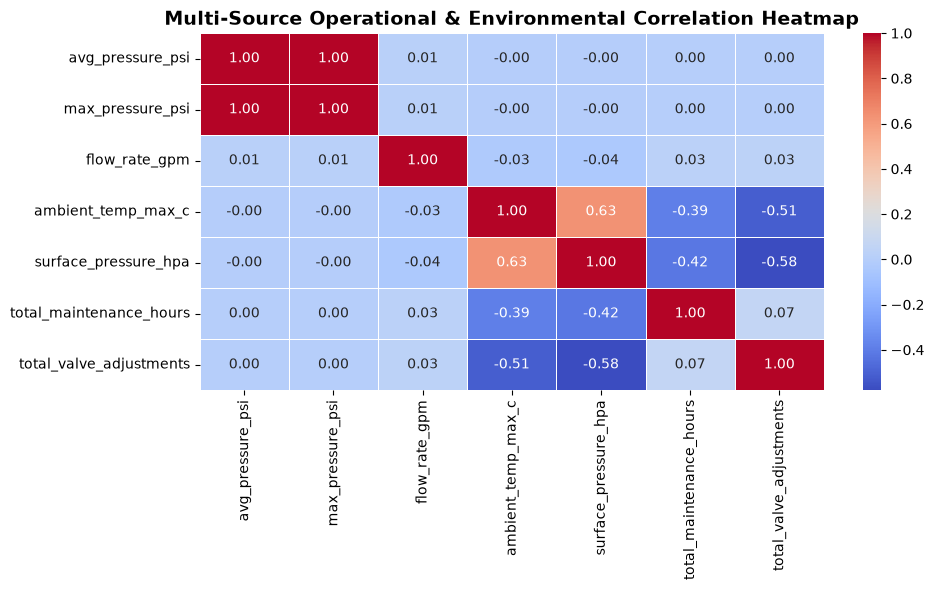

Correlation relative to Average Pipeline Pressure (avg_pressure_psi):
avg_pressure_psi           1.000000
max_pressure_psi           1.000000
flow_rate_gpm              0.014400
total_valve_adjustments    0.001570
total_maintenance_hours    0.001236
ambient_temp_max_c        -0.001409
surface_pressure_hpa      -0.001740
Name: avg_pressure_psi, dtype: float64


In [13]:
# ANALYSIS: CORRELATION HEATMAP

plt.figure(figsize=(10, 6))

corr_cols = [
    'avg_pressure_psi', 
    'max_pressure_psi', 
    'flow_rate_gpm', 
    'ambient_temp_max_c', 
    'surface_pressure_hpa', 
    'total_maintenance_hours', 
    'total_valve_adjustments'
]

# Pearson Correlation Matrix
corr_matrix = df_master[corr_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Multi-Source Operational & Environmental Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Correlation relative to Average Pipeline Pressure (avg_pressure_psi):")
print(corr_matrix['avg_pressure_psi'].sort_values(ascending=False))

In [14]:
# DOCUMENTATION: COLUMN DICTIONARY

column_documentation = {
    # Cleaned Source 1
    "date": "SOURCE 1 (ops_sensor_log_dirty.csv) / Shared Key: Timestamp representing the operational logging date.",
    "pipeline_id": "SOURCE 1 (ops_sensor_log_dirty.csv): Cleaned and trimmed pipeline identifier (PL-001).",
    "avg_pressure_psi": "SOURCE 1 (ops_sensor_log_dirty.csv): Mean operating pressure with imputed missing values.",
    "max_pressure_psi": "SOURCE 1 (ops_sensor_log_dirty.csv): Peak estimated operating pressure in PSI.",
    "flow_rate_gpm": "SOURCE 1 (ops_sensor_log_dirty.csv): Fluid throughput in Gallons Per Minute.",
    
    # Source 2
    "ambient_temp_max_c": "SOURCE 2 (External API - Open-Meteo): Maximum daily ambient temperature in °C.",
    "surface_pressure_hpa": "SOURCE 2 (External API - Open-Meteo): Maximum surface atmospheric pressure in hPa.",
    "daily_precipitation_mm": "SOURCE 2 (External API - Open-Meteo): Accumulated daily precipitation in mm.",
    
    # Source 3
    "total_maintenance_hours": "SOURCE 3 (SQLite DB - SQL JOIN/GROUP BY): Total daily engineering maintenance hours across active units.",
    "total_valve_adjustments": "SOURCE 3 (SQLite DB - SQL JOIN/GROUP BY): Total recorded physical valve adjustments.",
    "active_units_count": "SOURCE 3 (SQLite DB - SQL JOIN/GROUP BY): Count of active pipeline operating units reporting."
}

print("==========================================================================")
print("                   MASTER DATAFRAME COLUMN DOCUMENTATION                  ")
print("==========================================================================")
for col, desc in column_documentation.items():
    print(f"• {col.ljust(25)} : {desc}")
print("==========================================================================")

                   MASTER DATAFRAME COLUMN DOCUMENTATION                  
• date                      : SOURCE 1 (ops_sensor_log_dirty.csv) / Shared Key: Timestamp representing the operational logging date.
• pipeline_id               : SOURCE 1 (ops_sensor_log_dirty.csv): Cleaned and trimmed pipeline identifier (PL-001).
• avg_pressure_psi          : SOURCE 1 (ops_sensor_log_dirty.csv): Mean operating pressure with imputed missing values.
• max_pressure_psi          : SOURCE 1 (ops_sensor_log_dirty.csv): Peak estimated operating pressure in PSI.
• flow_rate_gpm             : SOURCE 1 (ops_sensor_log_dirty.csv): Fluid throughput in Gallons Per Minute.
• ambient_temp_max_c        : SOURCE 2 (External API - Open-Meteo): Maximum daily ambient temperature in °C.
• surface_pressure_hpa      : SOURCE 2 (External API - Open-Meteo): Maximum surface atmospheric pressure in hPa.
• daily_precipitation_mm    : SOURCE 2 (External API - Open-Meteo): Accumulated daily precipitation in mm.
• total_ma